# Maestría en Inteligencia Artificial
## Matemáticas y Programación para IA
### Proyecto: Detección de Suplantación de Identidad mediante Dinámica de Mouse y Detección de Anomalías

---

### **Contexto y Pregunta de Investigación**
> **Pregunta principal.** ¿Qué tan bien las características temporales y cinemáticas del mouse permiten distinguir sesiones legítimas e impostoras en diez usuarios, y qué muestra el caso de `user12` sobre la posibilidad de detectar una suplantación de manera temprana?

### Preguntas específicas del proyecto

1. ¿Cuál es el desempeño promedio de los modelos en las diez cuentas?
2. ¿Cuánto varían la separabilidad, la FAR y la FRR entre usuarios?
3. En `user12`, ¿cómo cambia la detección al observar entre 25 y 150 eventos y existe un mínimo que satisfaga el criterio operativo?
4. En ese caso, ¿qué características discriminan mejor y qué tan estable es el comportamiento legítimo entre sesiones?



---
## Parte 0: Configuración reproducible

Esta sección impnorta las dependencias, fija el estilo de las figuras y localiza las carpetas del proyecto.

Comprobar las rutas y las dependencias al comienzo permite detectar fallos antes de ejecutar una extracción costosa. La celda también prepara una ejecución reproducible mediante una semilla fija para el modelo estocástico.


In [1]:
# Biblioteca estándar: archivos, fórmulas y estadísticos simples.
import math
import csv
import statistics
from pathlib import Path
from typing import Sequence

# Datos tabulares y cálculo vectorizado.
import numpy as np
import pandas as pd

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Preprocesamiento, modelo y evaluación.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score

# Configuración visual
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Búsqueda robusta de datos: funciona desde raíz o desde subcarpeta notebook
candidates = [Path.cwd() / "data", Path.cwd() / "notebook" / "data"]
DATA_DIR = next((p.resolve() for p in candidates if (p / "public_labels.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontró data/public_labels.csv. Abre Jupyter desde la carpeta del proyecto."
    )
NOTEBOOK_DIR = DATA_DIR.parent

# Usamos el reloj del cliente para derivadas cinemáticas; se justifica en la Parte 1.
TIME_COLUMN = "client timestamp"

print(f"Directorio de trabajo: {Path.cwd().resolve()}")
print(f"Directorio de datos: {DATA_DIR} (existe: {DATA_DIR.exists()})")
print(f"Reloj usado para cinemática: {TIME_COLUMN}")

Directorio de trabajo: /Users/alech/Documents/notes/Obsidian/posgrado/master/MATEMÁTICAS Y PROGRAMACIÓN IA/proyecto/notebook
Directorio de datos: /Users/alech/Documents/notes/Obsidian/posgrado/master/MATEMÁTICAS Y PROGRAMACIÓN IA/proyecto/notebook/data (existe: True)
Reloj usado para cinemática: client timestamp


---
## Parte 1: Ingesta, Inspección y Visualización de Trayectorias Raw

Cada sesión de interacción de mouse en el dataset Balabit se almacena en un archivo CSV con las columnas:
* `record timestamp`: Marca de tiempo en segundos (monótona creciente).
* `client timestamp`: Marca de tiempo del cliente.
* `button`: Botón presionado (`NoButton`, `Left`, `Right`, `Scroll`).
* `state`: Estado del puntero (`Move`, `Pressed`, `Released`, `Drag`).
* `x`, `y`: Coordenadas espaciales en la pantalla (píxeles).

La [documentación oficial de Balabit](https://github.com/balabit/Mouse-Dynamics-Challenge#session-files) distingue dos relojes: el monitor de red registra **record timestamp** y el cliente RDP registra **client timestamp**.

Para calcular velocidad y aceleración usamos el reloj del cliente, que está más cerca del instante en que se generó el evento. El reloj de red también refleja la agrupación y el retraso de los paquetes. Ninguno se considera perfecto, de modo que antes de elegir se mide cuántos intervalos repetidos presenta cada reloj.

Este notebook es autocontenido. Antes de comparar sus métricas con las producidas por el paquete reutilizable en **src/mouse_auth**, es necesario verificar que ambos usen la misma columna temporal, porque una diferencia de reloj cambia la velocidad, la aceleración y el modelo final.

Cuando muchos intervalos valen cero, dividir distancia entre tiempo produciría velocidades indefinidas o artificialmente grandes. Se conservan todos los puntos para describir la geometría, pero solo los segmentos con $\Delta t>0$ participan en el cálculo de velocidad.

Veamos cómo cargar e inspeccionar una sesión real.


In [2]:
def load_raw_session(file_path: Path) -> pd.DataFrame:
    """Carga y valida un archivo de sesión CSV de Balabit."""
    df = pd.read_csv(file_path)
    required = {"record timestamp", "client timestamp", "button", "state", "x", "y"}
    if not required.issubset(df.columns):
        raise ValueError(f"Faltan columnas requeridas en {file_path}")
    
    # 1) Orden temporal estable: los empates conservan el orden original del CSV.
    df = df.sort_values(by=TIME_COLUMN, kind="mergesort").reset_index(drop=True)

    # 2) Diferencias entre eventos consecutivos.
    df["dt"] = df[TIME_COLUMN].diff().fillna(0.0)
    df["dx"] = df["x"].diff().fillna(0.0)
    df["dy"] = df["y"].diff().fillna(0.0)
    df["distance"] = np.hypot(df["dx"], df["dy"])
    
    # 3) División segura: np.where evaluaría también distance / 0 y puede advertir.
    speed = np.zeros(len(df), dtype=float)
    valid_time = df["dt"].to_numpy() > 0.0
    np.divide(
        df["distance"].to_numpy(),
        df["dt"].to_numpy(),
        out=speed,
        where=valid_time,
    )
    df["speed"] = speed
    return df

# Seleccionamos una sesión de ejemplo de user7
sample_train_file = sorted((DATA_DIR / "training_files" / "user7").glob("session_*"))[0]
df_sample = load_raw_session(sample_train_file)
print(f"Sesión de ejemplo: {sample_train_file.name}")
print(f"Total eventos: {len(df_sample)}")
for clock in ["record timestamp", "client timestamp"]:
    duplicate_fraction = df_sample[clock].diff().eq(0.0).mean()
    print(f"Intervalos repetidos en {clock:16s}: {duplicate_fraction:.1%}")
df_sample.head()


Sesión de ejemplo: session_0041905381
Total eventos: 83091
Intervalos repetidos en record timestamp: 71.4%
Intervalos repetidos en client timestamp: 6.9%


,record timestamp,client timestamp,button,state,x,y,dt,dx,dy,distance,speed
0,0.0,0.000,NoButton,Move,126,337,0.000,0.0,0.0,0.000000,0.000000
1,0.0,0.016,NoButton,Move,129,337,0.016,3.0,0.0,3.000000,187.499999
2,0.0,0.032,NoButton,Move,136,337,0.016,7.0,0.0,7.000000,437.500005
3,0.0,0.047,NoButton,Move,155,339,0.015,19.0,2.0,19.104973,1273.664867
4,0.0,0.063,NoButton,Move,185,340,0.016,30.0,1.0,30.016662,1876.041370


### Visualización cinemática de una sesión
Graficamos la trayectoria espacial 2D $(x, y)$ coloreada por tiempo y el perfil de velocidad $v(t)=\frac{\Delta s}{\Delta t}$.

La trayectoria muestra *dónde* se movió el puntero, mientras que la velocidad muestra *cómo* cambió el movimiento con el tiempo. Dos sesiones pueden recorrer zonas parecidas y, aun así, tener ritmos muy distintos.

> Los picos no deben interpretarse automáticamente como rasgos del usuario: también pueden aparecer por intervalos muy pequeños, muestreo irregular o saltos de coordenadas.


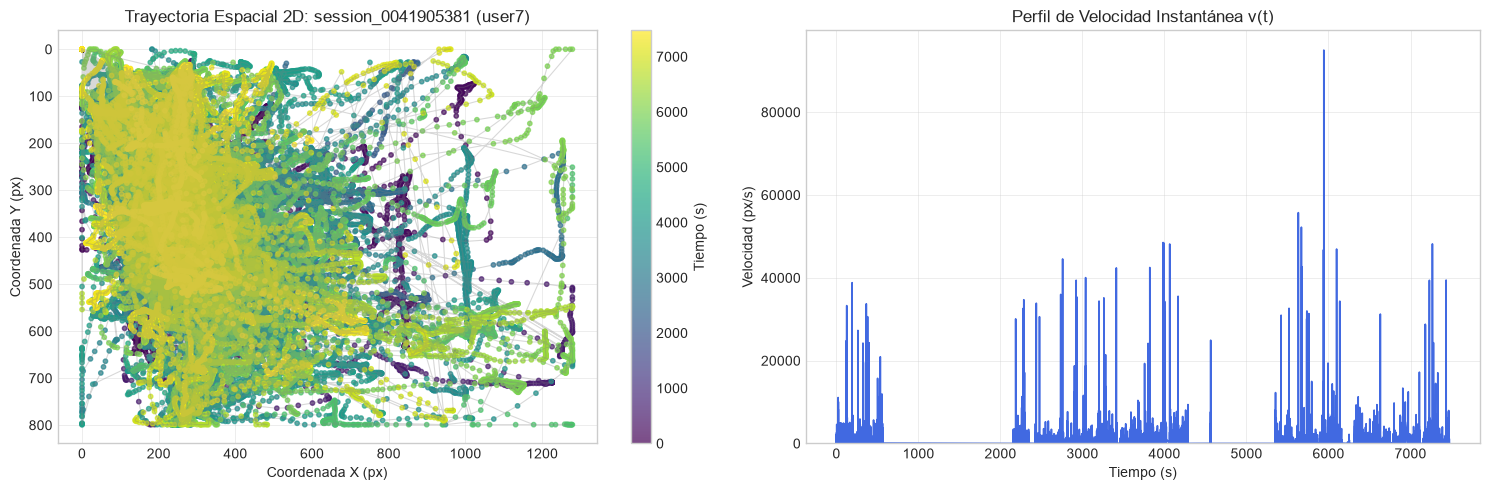

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: geometría. El color indica el orden temporal.
sc = axes[0].scatter(df_sample["x"], df_sample["y"], c=df_sample[TIME_COLUMN], cmap="viridis", s=10, alpha=0.7)
axes[0].plot(df_sample["x"], df_sample["y"], color="gray", alpha=0.3, linewidth=0.8)
axes[0].set_title(f"Trayectoria Espacial 2D: {sample_train_file.name} (user7)")
axes[0].set_xlabel("Coordenada X (px)")
axes[0].set_ylabel("Coordenada Y (px)")
axes[0].invert_yaxis()  # En coordenadas de pantalla, y=0 está arriba
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label("Tiempo (s)")

# Panel derecho: dinámica. Solo dt > 0 produjo velocidades distintas de cero.
axes[1].plot(df_sample[TIME_COLUMN], df_sample["speed"], color="royalblue", lw=1.2)
axes[1].set_title("Perfil de Velocidad Instantánea v(t)")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Velocidad (px/s)")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


---
## Parte 2: De una trayectoria a 17 características

Cada sesión comienza como miles de eventos ordenados y termina representada por un vector $\mathbf{x}\in\mathbb{R}^{17}$ que Isolation Forest puede comparar con las demás sesiones.

El número de eventos cambia entre sesiones, pero un modelo tabular necesita una forma fija. Resumir la trayectoria resuelve esa incompatibilidad a cambio de perder parte del orden fino, por lo que cada característica debe conservar una interpretación clara y una prueba de sanidad.

Las características elegidas son estadísticas y cantidades cinemáticas invariantes a traslación espacial:

### 1. Frecuencias y Conteos
* $\text{event\_count} = N$: Número total de eventos.
* $\text{move\_count}$: Eventos con $\text{state} = \text{'Move'}$.
* $\text{click\_count}$: Proxy de interacción; cuenta eventos con botón activo o estado distinto de Move. **No equivale al número de clics completos**, porque un clic puede generar Pressed y Released y un arrastre varios eventos.
* $\text{duration\_s} = t_N - t_1$: Duración total de la sesión.
* $\text{event\_rate\_hz} = \frac{N}{\text{duration\_s}}$: Frecuencia de muestreo efectiva.

### 2. Cinemática Espacial
* $\text{path\_length\_px} = \sum_{i=1}^{N-1} \sqrt{(x_{i+1}-x_i)^2 + (y_{i+1}-y_i)^2}$: Longitud total del camino recorrido.
* $\text{net\_displacement\_px} = \sqrt{(x_N-x_1)^2 + (y_N-y_1)^2}$: Desplazamiento neto origen-destino.
* $\text{path\_efficiency} = \frac{\text{net\_displacement\_px}}{\text{path\_length\_px}} \in [0, 1]$: Eficiencia de trayectoria (1 = línea recta perfecta).

### 3. Dinámica y Derivadas (Velocidad, Aceleración, Curvatura)
* Segmentos válidos: $\Delta t_i = t_{i+1} - t_i > 0$.
* Velocidad: $v_i = \frac{\Delta s_i}{\Delta t_i}$. Métricas: $\mu_v$, $\sigma_v$, $\max(v)$.
* Aceleración: $a_i = \frac{|v_{i+1} - v_i|}{\Delta t_{v, i}}$. Métricas: $\mu_a$, $\sigma_a$.
* Ángulo de trayectoria: $\theta_i = \text{atan2}(\Delta y_i, \Delta x_i)$.
* Cambio angular envuelto: $\Delta \theta_i = (\theta_{i+1} - \theta_i + \pi) \pmod{2\pi} - \pi$. Métrica: $\mu_{|\Delta\theta|}$.

### 4. Comportamiento de Pausas
* Una pausa operativa se define cuando $\Delta t_i \ge 0.5\text{ s}$.
* $\text{pause\_count}$, $\text{pause\_fraction} = \frac{\text{pauses}}{N - 1}$.
* $\text{valid\_segment\_fraction} = \frac{\#\{i : \Delta t_i > 0\}}{N - 1}$.

Una separación temporal grande se interpreta aquí como una pausa entre eventos, no necesariamente como una pausa cognitiva deliberada. Del mismo modo, la velocidad y la aceleración dependen de la resolución del reloj elegido.


In [4]:
FEATURE_NAMES = [
    "event_count",
    "move_count",
    "click_count",
    "duration_s",
    "event_rate_hz",
    "path_length_px",
    "net_displacement_px",
    "path_efficiency",
    "speed_mean",
    "speed_std",
    "speed_max",
    "acceleration_abs_mean",
    "acceleration_abs_std",
    "angle_change_abs_mean",
    "pause_count",
    "pause_fraction",
    "valid_segment_fraction",
]

def _wrapped_angle_diff(a: float, b: float) -> float:
    """Calcula la diferencia angular mínima en [-pi, pi]."""
    return (a - b + math.pi) % (2.0 * math.pi) - math.pi

def extract_session_features(path: str | Path) -> dict[str, float]:
    """Extrae de forma determinista y robusta el vector de 17 características de una sesión."""
    session_path = Path(path)
    events: list[tuple[float, float, float, str, str]] = []
    
    # A) Leer y validar: fallar aquí es mejor que propagar NaN al modelo.
    with session_path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        required = {TIME_COLUMN, "button", "state", "x", "y"}
        if not required.issubset(reader.fieldnames or []):
            raise ValueError(f"Faltan columnas requeridas en {session_path}")

        for line_number, row in enumerate(reader, start=2):
            try:
                t = float(row[TIME_COLUMN])
                x = float(row["x"])
                y = float(row["y"])
            except (TypeError, ValueError) as error:
                raise ValueError(f"Fila inválida {session_path}:{line_number}") from error
            if not all(math.isfinite(value) for value in (t, x, y)):
                raise ValueError(f"Valor no finito {session_path}:{line_number}")
            events.append((t, x, y, row["button"], row["state"]))
            
    if len(events) < 2:
        raise ValueError(f"La sesión necesita al menos 2 eventos: {session_path}")
        
    # B) Ordenar y construir segmentos consecutivos.
    events.sort(key=lambda e: e[0])
    duration = max(0.0, events[-1][0] - events[0][0])
    
    distances, speeds, speed_times, angles = [], [], [], []
    pauses = 0
    
    for prev, curr in zip(events, events[1:]):
        dt = curr[0] - prev[0]
        dx = curr[1] - prev[1]
        dy = curr[2] - prev[2]
        dist = math.hypot(dx, dy)
        distances.append(dist)
        
        if dt <= 0.0:
            continue
        speed = dist / dt
        speeds.append(speed)
        speed_times.append(curr[0])
        if dist > 0.0:
            angles.append(math.atan2(dy, dx))
        if dt >= 0.5:
            pauses += 1
            
    # C) Derivada discreta de la velocidad en segmentos temporales válidos.
    accelerations = []
    for i in range(1, len(speeds)):
        dt_speed = speed_times[i] - speed_times[i - 1]
        if dt_speed > 0.0:
            accelerations.append(abs(speeds[i] - speeds[i - 1]) / dt_speed)
            
    # D) Resumir toda la sesión con estadísticos de tamaño fijo.
    angle_changes = [abs(_wrapped_angle_diff(a, b)) for a, b in zip(angles[1:], angles[:-1])]
    path_len = sum(distances)
    displacement = math.hypot(events[-1][1] - events[0][1], events[-1][2] - events[0][2])
    move_count = sum(state.lower() == "move" for _, _, _, _, state in events)
    # Proxy de eventos de interacción; no representa clics completos únicos.
    click_count = sum(btn.lower() != "nobutton" or state.lower() != "move" for _, _, _, btn, state in events)
    possible_segs = len(events) - 1
    
    features = {
        "event_count": float(len(events)),
        "move_count": float(move_count),
        "click_count": float(click_count),
        "duration_s": duration,
        "event_rate_hz": len(events) / duration if duration > 0.0 else 0.0,
        "path_length_px": path_len,
        "net_displacement_px": displacement,
        "path_efficiency": displacement / path_len if path_len > 0.0 else 0.0,
        "speed_mean": statistics.fmean(speeds) if speeds else 0.0,
        "speed_std": statistics.pstdev(speeds) if len(speeds) > 1 else 0.0,
        "speed_max": max(speeds, default=0.0),
        "acceleration_abs_mean": statistics.fmean(accelerations) if accelerations else 0.0,
        "acceleration_abs_std": statistics.pstdev(accelerations) if len(accelerations) > 1 else 0.0,
        "angle_change_abs_mean": statistics.fmean(angle_changes) if angle_changes else 0.0,
        "pause_count": float(pauses),
        "pause_fraction": pauses / possible_segs,
        "valid_segment_fraction": len(speeds) / possible_segs,
    }

    # E) Contrato de salida: mismo orden, 17 valores finitos en toda sesión.
    if list(features) != FEATURE_NAMES or not all(math.isfinite(v) for v in features.values()):
        raise AssertionError("El contrato de las 17 características se rompió")
    return features

# Prueba sobre la sesión de ejemplo
feats_sample = extract_session_features(sample_train_file)
pd.DataFrame([feats_sample]).T.rename(columns={0: "Valor"})


,Valor
event_count,83091.000000
move_count,69930.000000
click_count,13161.000000
duration_s,7473.728000
event_rate_hz,11.117745
path_length_px,996518.005322
net_displacement_px,203.666394
path_efficiency,0.000204
speed_mean,482.899718
speed_std,1765.796084


### Prueba de sanidad: invarianza a traslación
Comprobamos que mover toda la trayectoria por un desplazamiento constante $(x+\Delta x,y+\Delta y)$ no cambia las características cinemáticas y dinámicas.

La posición absoluta depende de la resolución, el monitor y la ubicación de las ventanas. Este baseline pretende describir *cómo* se mueve el usuario, no en qué esquina estaba una aplicación; la prueba documenta ese supuesto y avisará si una modificación futura lo rompe.


In [5]:
import tempfile

def test_invariance() -> None:
    """Arrange: dos CSV trasladados; Act: features; Assert: mismo vector."""
    with tempfile.TemporaryDirectory() as tmp_dir:
        p1 = Path(tmp_dir) / "s1.csv"
        p2 = Path(tmp_dir) / "s2.csv"
        
        # ARRANGE: crear dos sesiones idénticas salvo un offset de +500 px.
        with p1.open("w", newline="") as f1, p2.open("w", newline="") as f2:
            w1, w2 = csv.writer(f1), csv.writer(f2)
            cols = ["record timestamp", "client timestamp", "button", "state", "x", "y"]
            w1.writerow(cols); w2.writerow(cols)
            w1.writerows([[0.0, 0.0, "NoButton", "Move", 10.0, 10.0],
                          [1.0, 1.0, "NoButton", "Move", 13.0, 14.0],
                          [2.0, 2.0, "Left", "Pressed", 16.0, 18.0]])
            w2.writerows([[0.0, 0.0, "NoButton", "Move", 510.0, 510.0],
                          [1.0, 1.0, "NoButton", "Move", 513.0, 514.0],
                          [2.0, 2.0, "Left", "Pressed", 516.0, 518.0]])
            
        # ACT: resumir cada trayectoria con la misma función usada por el modelo.
        f_s1 = extract_session_features(p1)
        f_s2 = extract_session_features(p2)
        
        # ASSERT: cada característica debe coincidir dentro de tolerancia numérica.
        for k in f_s1:
            assert np.isclose(f_s1[k], f_s2[k]), f"Fallo en {k}"
        print("✓ Test de invarianza a traslación superado con éxito.")

test_invariance()


✓ Test de invarianza a traslación superado con éxito.


---
## Parte 3: Partición por sesión sin fuga de información

En autenticación biométrica continua, **evitar la fuga de información (data leakage)** es crítico:
1. **Separación por sesión**: Jamás mezclar eventos de una misma sesión en particiones distintas.
2. **Entrenamiento y Calibración**:
   * **Enrolamiento ($75\%$)**: Sesiones exclusivamente legítimas del usuario para calcular medias/desviaciones del `StandardScaler` y entrenar el modelo de anomalías.
   * **Validación ($25\%$)**: Sesiones exclusivamente legítimas del usuario, utilizadas *únicamente* para fijar el umbral de tolerancia.
   * **Test**: Sesiones mixtas (legítimas e impostoras simuladas). El umbral **no** se adapta al test.

El enrolamiento ajusta el escalador y el modelo, la validación legítima fija el umbral y el conjunto de test se usa una sola vez para medir. Las etiquetas públicas de test jamás entran al escalador, al bosque ni al umbral operativo.

Las rutas se ordenan por nombre y las últimas sesiones forman la validación. La separación es determinista, no aleatoria, y no supone que el identificador represente el tiempo. Como hay pocas sesiones, el resultado depende mucho de cuáles quedan fuera; la Parte 8 propone evaluar esa sensibilidad con validación *leave-one-session-out*.


In [6]:
def load_public_labels(labels_path: Path) -> dict[str, int]:
    """Carga las etiquetas públicas: 0 = legítimo, 1 = impostor/ilegal."""
    with labels_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        labels = {row["filename"]: int(row["is_illegal"]) for row in reader}
    if set(labels.values()) - {0, 1}:
        raise ValueError("Las etiquetas públicas deben ser binarias: 0 o 1")
    return labels

def split_training_sessions(paths: list[Path], validation_fraction: float = 0.25) -> tuple[list[Path], list[Path]]:
    """Reserva las últimas rutas ordenadas para validación; conserva al menos 2 en enrolamiento."""
    if not 0.0 < validation_fraction < 1.0:
        raise ValueError("validation_fraction debe estar entre 0 y 1")
    if len(paths) < 3:
        raise ValueError("Se requieren al menos 3 sesiones de training")
    val_count = max(1, round(len(paths) * validation_fraction))
    val_count = min(val_count, len(paths) - 2)
    return paths[:-val_count], paths[-val_count:]

labels_dict = load_public_labels(DATA_DIR / "public_labels.csv")
print(f"Total etiquetas públicas cargadas: {len(labels_dict)}")


Total etiquetas públicas cargadas: 816


---
## Parte 4: Dos modelos de anomalías de una clase

Los modelos reciben tres matrices de 17 columnas correspondientes a enrolamiento, validación y test. A cada sesión de validación y test le asignan una puntuación continua que aumenta cuando la sesión parece más anómala.

Como el enrolamiento contiene solo sesiones legítimas, formulamos el problema como **detección de anomalías de una clase**. No se enseña al modelo qué aspecto tiene cada impostor; se aprende una región de comportamiento habitual y se mide cuánto se aleja una sesión nueva.

### Paso común: StandardScaler
Las características tienen unidades muy diferentes —eventos, segundos, píxeles y radianes—. Ajustamos media y desviación **solo en enrolamiento** y aplicamos esa misma transformación a validación y test. Ajustarla con test filtraría información futura.

### 1. Modelo de Referencia: RMS-z Score
Estandarizamos las características con el perfil de enrolamiento:
$$z_j = \frac{x_j - \mu_{j, \text{enroll}}}{\sigma_{j, \text{enroll}}}$$
El score de anomalía es la raíz de la media de los cuadrados de los z-scores:
$$S_{\text{RMS}}(\mathbf{x}) = \sqrt{\frac{1}{D} \sum_{j=1}^D z_j^2}$$

### 2. Modelo Principal: Isolation Forest
* Construye un ensamble de árboles de aislamiento aleatorios ($T=200$).
* Los puntos anómalos quedan aislados cerca de la raíz (menor longitud de camino promedio $E(h(\mathbf{x}))$).
* Convertimos la salida a una convención de anomalía monótona: $\text{score} = -\text{score\_samples}(\mathbf{x})$ (mayor score = más anómalo).

RMS-z funciona como una referencia transparente, mientras que Isolation Forest puede captar combinaciones no lineales. Si el modelo complejo no supera al baseline, conviene revisar los datos, las características y la calibración antes de atribuir el problema a una falta de complejidad.

Cada usuario dispone de muy pocas sesiones de enrolamiento frente a 17 variables, por lo que los resultados deben interpretarse como exploratorios.


In [7]:
def compute_rms_scores(matrix_z: np.ndarray) -> np.ndarray:
    """Calcula el score RMS-z para una matriz estandarizada (N, D)."""
    return np.sqrt(np.mean(matrix_z ** 2, axis=1))

def train_and_score_models(enroll_feat: np.ndarray, val_feat: np.ndarray, test_feat: np.ndarray, random_state: int = 7):
    """Ajusta el scaler y modelos en enrolamiento y genera scores para val y test."""
    if enroll_feat.ndim != 2 or enroll_feat.shape[1] != len(FEATURE_NAMES):
        raise ValueError("enroll_feat debe tener forma (sesiones, 17 características)")

    # 1) Aprender unidades y escala exclusivamente del comportamiento legítimo enrolado.
    scaler = StandardScaler().fit(enroll_feat)
    
    enroll_z = scaler.transform(enroll_feat)
    val_z = scaler.transform(val_feat)
    test_z = scaler.transform(test_feat)
    
    # 2) Baseline interpretable: distancia RMS en coordenadas estandarizadas.
    val_scores_rms = compute_rms_scores(val_z)
    test_scores_rms = compute_rms_scores(test_z)
    
    # 3) Modelo no lineal: aislar puntos con particiones aleatorias.
    # contamination no fija nuestro umbral; aquí solo usamos score_samples.
    iso_forest = IsolationForest(n_estimators=200, contamination="auto", random_state=random_state)
    iso_forest.fit(enroll_z)
    
    val_scores_if = -iso_forest.score_samples(val_z)
    test_scores_if = -iso_forest.score_samples(test_z)
    
    # 4) Devolver scores, no clases: el umbral se aprende después con validación.
    return {
        "rms_z": (val_scores_rms, test_scores_rms),
        "isolation_forest": (val_scores_if, test_scores_if)
    }


---
## Parte 5: Del score a una decisión — umbral y métricas

El modelo entrega un número continuo; una aplicación necesita decidir **aceptar** o **generar alarma**. Usamos la regla: alarma si $score>umbral$. La igualdad se acepta por convención, algo importante cuando validación contiene una sola sesión.

### Definición de Métricas Biométricas
* **Etiqueta 1**: Impostor / Ilegal.
* **Predicción 1**: Alarma de anomalía (se rechaza la sesión).
* **FAR (False Acceptance Rate)**: Impostores aceptados erróneamente (falla de seguridad):
  $$\text{FAR} = \frac{\text{FN}}{\text{TP} + \text{FN}}$$
* **FRR (False Rejection Rate)**: Legítimos rechazados erróneamente (falla de usabilidad):
  $$\text{FRR} = \frac{\text{FP}}{\text{TN} + \text{FP}}$$
* **F1-Score de Impostor**: $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$.

### Calibración de Umbral
Fijamos el cuantil de tolerancia en validación legítima $q=0.95$. En una muestra grande, esto aproxima una cola legítima del $5\%$; con solo 1–2 sesiones **no garantiza** un FRR de $5\%$ y es una estimación muy inestable.

El umbral operativo se fija sin consultar las etiquetas de test. Las etiquetas se usan únicamente después para medir AUC, FAR, FRR, F1 y exactitud.


In [8]:
def calculate_classification_metrics(labels: Sequence[int], preds: Sequence[int]) -> dict[str, float | int]:
    """Calcula métricas binarias de biometría y clasificación."""
    if len(labels) != len(preds) or len(labels) == 0:
        raise ValueError("labels y preds deben tener igual longitud no vacía")
    if set(labels) - {0, 1} or set(preds) - {0, 1}:
        raise ValueError("Solo se admiten etiquetas y predicciones binarias")

    labels_arr = np.array(labels)
    preds_arr = np.array(preds)
    
    tp = int(np.sum((labels_arr == 1) & (preds_arr == 1)))
    fp = int(np.sum((labels_arr == 0) & (preds_arr == 1)))
    fn = int(np.sum((labels_arr == 1) & (preds_arr == 0)))
    tn = int(np.sum((labels_arr == 0) & (preds_arr == 0)))
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2.0 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    far = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    frr = fp / (tn + fp) if (tn + fp) > 0 else 0.0
    acc = (tp + tn) / len(labels) if len(labels) > 0 else 0.0
    
    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision_impostor": prec, "recall_impostor": rec, "f1_impostor": f1,
        "far": far, "frr": frr, "accuracy": acc
    }


---
## Parte 6: Pipeline completo por usuario

Ejecutamos el flujo de trabajo completo sobre los **10 usuarios** del dataset Balabit:
1. Extraer características de las sesiones de entrenamiento y separar en Enrolamiento y Validación.
2. Extraer características del subconjunto de sesiones de Test con etiqueta pública.
3. Ajustar `StandardScaler` e `IsolationForest` sobre Enrolamiento.
4. Determinar el umbral en Validación ($q = 0.95$).
5. Clasificar el Test y registrar predicciones y métricas.

Se ajusta un modelo por usuario porque la pregunta no es «¿qué persona es?», sino «¿esta sesión se parece al propietario de esta cuenta?». Cada usuario define así su propia referencia y su propio umbral.

El resultado conserva una fila por usuario, sesión y modelo, además de un resumen de métricas por cuenta. Mantener juntas las puntuaciones y las decisiones permite auditar después cualquier resultado agregado.


In [9]:
VALIDATION_QUANTILE = 0.95

def run_full_pipeline(data_dir: Path) -> tuple[pd.DataFrame, dict[str, dict]]:
    """Ejecuta el mismo protocolo independiente para cada cuenta."""
    # Las etiquetas se usarán solo al evaluar test, nunca para ajustar el modelo.
    labels = load_public_labels(data_dir / "public_labels.csv")
    users = sorted(p.name for p in (data_dir / "training_files").iterdir() if p.is_dir())
    
    all_predictions = []
    user_summaries = {}
    
    for user in users:
        # A) Construir particiones por sesión para una sola cuenta.
        train_paths = sorted((data_dir / "training_files" / user).glob("session_*"))
        all_test_paths = sorted((data_dir / "test_files" / user).glob("session_*"))
        
        # La carpeta incluye test público y privado; evaluamos solo nombres etiquetados.
        test_paths = [p for p in all_test_paths if p.name in labels]
        enroll_paths, val_paths = split_training_sessions(train_paths, validation_fraction=0.25)
        
        if not test_paths:
            raise ValueError(f"No hay sesiones públicas etiquetadas para {user}")

        # B) Convertir cada sesión variable en una fila de 17 características.
        X_enroll = np.array([[extract_session_features(p)[name] for name in FEATURE_NAMES] for p in enroll_paths])
        X_val = np.array([[extract_session_features(p)[name] for name in FEATURE_NAMES] for p in val_paths])
        X_test = np.array([[extract_session_features(p)[name] for name in FEATURE_NAMES] for p in test_paths])
        y_test = [labels[p.name] for p in test_paths]
        
        # C) Ajustar únicamente con enrolamiento y puntuar val/test.
        model_scores = train_and_score_models(X_enroll, X_val, X_test)
        
        # D) Calibrar un umbral propio para cada combinación usuario-modelo.
        user_metrics = {}
        for model_name, (val_sc, test_sc) in model_scores.items():
            # El cuantil usa solo scores legítimos de validación.
            th = float(np.quantile(val_sc, VALIDATION_QUANTILE))
            preds = [int(s > th) for s in test_sc]
            m = calculate_classification_metrics(y_test, preds)
            auc = float(roc_auc_score(y_test, test_sc))
            user_metrics[model_name] = {
                **m,
                "threshold_validation": th,
                "auc_roc_test": auc,
            }
            
            for p, y, s, pred in zip(test_paths, y_test, test_sc, preds):
                all_predictions.append({
                    "user": user,
                    "session": p.name,
                    "model": model_name,
                    "label_is_illegal": y,
                    "score_anomaly": float(s),
                    "threshold": th,
                    "prediction_alarm": pred
                })
        # E) Guardar el detalle antes de pasar al siguiente usuario.
        user_summaries[user] = user_metrics
        print(f"✓ Usuario {user:6s}: {len(enroll_paths)} enrol | {len(val_paths)} val | {len(test_paths)} test")
        
    df_preds = pd.DataFrame(all_predictions)
    return df_preds, user_summaries

df_predictions, user_summaries = run_full_pipeline(DATA_DIR)


✓ Usuario user12: 5 enrol | 2 val | 105 test
✓ Usuario user15: 4 enrol | 2 val | 115 test
✓ Usuario user16: 4 enrol | 2 val | 106 test
✓ Usuario user20: 5 enrol | 2 val | 50 test
✓ Usuario user21: 5 enrol | 2 val | 59 test
✓ Usuario user23: 4 enrol | 2 val | 71 test
✓ Usuario user29: 5 enrol | 2 val | 63 test
✓ Usuario user35: 4 enrol | 1 val | 108 test
✓ Usuario user7 : 5 enrol | 2 val | 73 test
✓ Usuario user9 : 5 enrol | 2 val | 66 test


### Resultados por cuenta y promedio general
Primero se calculan las métricas de cada cuenta de forma independiente. Después se promedian para obtener el resultado general, de modo que cada usuario aporta el mismo peso aunque tenga un número distinto de sesiones públicas.

El **AUC ROC** mide si los impostores tienden a recibir puntuaciones mayores que los legítimos sin fijar un umbral concreto. El benchmark original de Balabit usó AUC global.

AUC evalúa el orden de las puntuaciones, mientras que FAR y FRR evalúan la decisión producida por el umbral de validación. Un AUC razonable acompañado de FAR o FRR deficientes sugiere un problema de calibración; un AUC cercano a $0.5$ sugiere poca separabilidad.


In [10]:
# Promedio general: cada cuenta aporta una vez a cada métrica.
general_results = []
for model_name in ["rms_z", "isolation_forest"]:
    f1s, accs, fars, frrs, aucs = [], [], [], [], []
    for u, u_metrics in user_summaries.items():
        m = u_metrics[model_name]
        f1s.append(m["f1_impostor"])
        accs.append(m["accuracy"])
        fars.append(m["far"])
        frrs.append(m["frr"])
        aucs.append(m["auc_roc_test"])
    general_results.append({
        "Modelo": "RMS-z" if model_name == "rms_z" else "Isolation Forest",
        "AUC": np.mean(aucs),
        "F1": np.mean(f1s),
        "Exactitud": np.mean(accs),
        "FAR": np.mean(fars),
        "FRR": np.mean(frrs)
    })

print("=== RESULTADOS GENERALES: PROMEDIO DE LAS DIEZ CUENTAS ===")
display(pd.DataFrame(general_results).set_index("Modelo"))


=== RESULTADOS GENERALES: PROMEDIO DE LAS DIEZ CUENTAS ===


,AUC,F1,Exactitud,FAR,FRR
Modelo,,,,,
RMS-z,0.627156,0.516321,0.486867,0.250006,0.711783
Isolation Forest,0.610861,0.505307,0.591393,0.342324,0.610352


---
## Parte 7: Leer los resultados antes de cambiar el modelo

Examinamos matrices de confusión, márgenes respecto del umbral y resultados por usuario. El objetivo es separar tres causas: **ranking deficiente de scores**, **umbral inestable** y **heterogeneidad entre cuentas**.

> Una exactitud agregada aislada no basta. En autenticación, aceptar impostores y rechazar legítimos tienen consecuencias diferentes; por eso se leen FAR y FRR por separado.


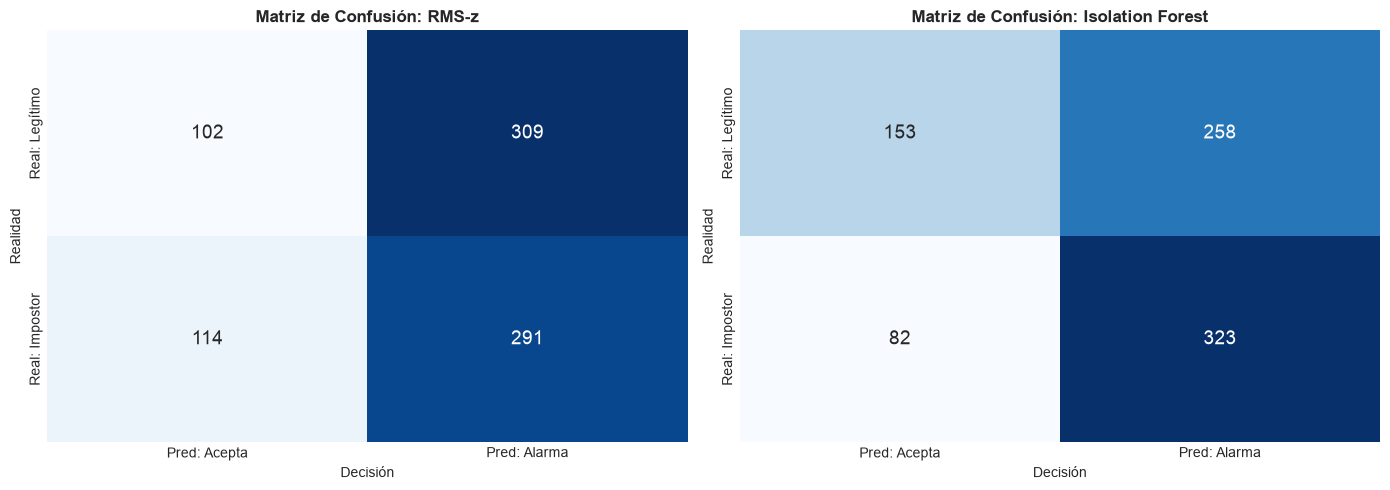

In [11]:
# Una matriz por modelo, usando la misma convención de filas y columnas.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, model_name in enumerate(["rms_z", "isolation_forest"]):
    sub = df_predictions[df_predictions["model"] == model_name]
    cm = pd.crosstab(
        sub["label_is_illegal"].map({0: "Real: Legítimo", 1: "Real: Impostor"}),
        sub["prediction_alarm"].map({0: "Pred: Acepta", 1: "Pred: Alarma"}),
        rownames=["Realidad"], colnames=["Decisión"]
    ).reindex(
        index=["Real: Legítimo", "Real: Impostor"],
        columns=["Pred: Acepta", "Pred: Alarma"],
        fill_value=0,
    )
    title = "Matriz de Confusión: RMS-z" if model_name == "rms_z" else "Matriz de Confusión: Isolation Forest"
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i], annot_kws={"size": 14})
    axes[i].set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


### Margen respecto del umbral: legítimos vs impostores
Cada usuario tiene un umbral distinto, por lo que mezclar scores brutos dificulta la lectura. Definimos $m=score-umbral$: $m>0$ produce alarma y $m\le0$ aceptación.

Una buena separación coloca las sesiones legítimas a la izquierda de cero y las impostoras a la derecha. El solapamiento cerca de cero revela decisiones sensibles a pequeñas variaciones.

> La KDE estima densidad y suaviza los datos; no representa conteos ni probabilidades calibradas.


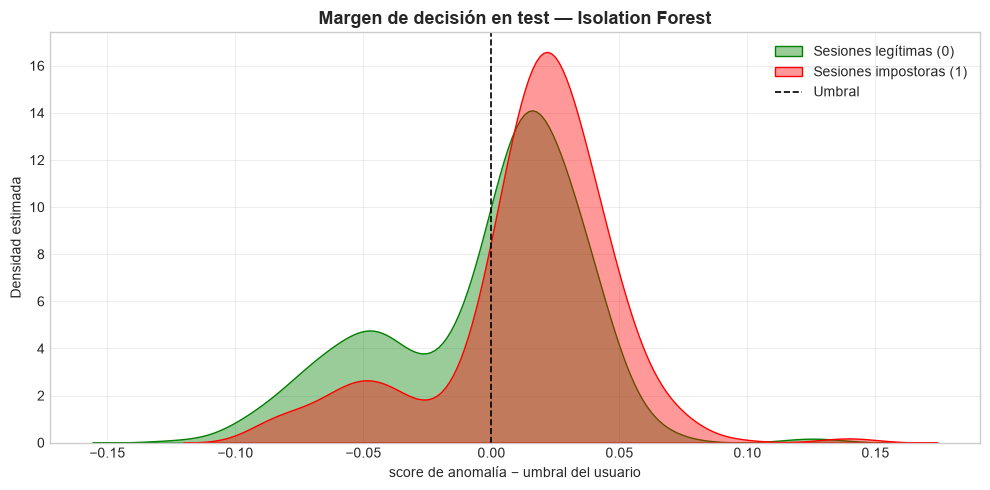

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

# Centrar cada score en el umbral de su propia cuenta hace visible la decisión.
sub_if = df_predictions[df_predictions["model"] == "isolation_forest"].copy()
sub_if["margin_to_threshold"] = sub_if["score_anomaly"] - sub_if["threshold"]
sns.kdeplot(data=sub_if[sub_if["label_is_illegal"] == 0], x="margin_to_threshold", label="Sesiones legítimas (0)", fill=True, color="green", alpha=0.4, ax=ax)
sns.kdeplot(data=sub_if[sub_if["label_is_illegal"] == 1], x="margin_to_threshold", label="Sesiones impostoras (1)", fill=True, color="red", alpha=0.4, ax=ax)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2, label="Umbral")

ax.set_title("Margen de decisión en test — Isolation Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("score de anomalía − umbral del usuario")
ax.set_ylabel("Densidad estimada")
ax.legend()
plt.tight_layout()
plt.show()


### Desglose por usuario
El promedio puede ocultar cuentas excelentes y cuentas inutilizables. AUC indica la separabilidad de los puntajes; FAR y FRR muestran el comportamiento del umbral individual en cada cuenta.


In [13]:
# Convertir el diccionario anidado en una tabla comparable por cuenta.
user_df_rows = []
for u, metrics in user_summaries.items():
    user_df_rows.append({
        "Usuario": u,
        "AUC (RMS-z)": metrics["rms_z"]["auc_roc_test"],
        "F1 (RMS-z)": metrics["rms_z"]["f1_impostor"],
        "FAR (RMS-z)": metrics["rms_z"]["far"],
        "FRR (RMS-z)": metrics["rms_z"]["frr"],
        "AUC (IF)": metrics["isolation_forest"]["auc_roc_test"],
        "F1 (IF)": metrics["isolation_forest"]["f1_impostor"],
        "FAR (IF)": metrics["isolation_forest"]["far"],
        "FRR (IF)": metrics["isolation_forest"]["frr"],
    })

df_users = pd.DataFrame(user_df_rows).set_index("Usuario")
display(df_users)


,AUC (RMS-z),F1 (RMS-z),FAR (RMS-z),FRR (RMS-z),AUC (IF),F1 (IF),FAR (IF),FRR (IF)
Usuario,,,,,,,,
user12,0.622813,0.636364,0.000000,1.000000,0.551931,0.635135,0.040816,0.928571
user15,0.464444,0.756757,0.000000,1.000000,0.678254,0.750000,0.057143,0.888889
user16,0.584752,0.527778,0.000000,1.000000,0.497291,0.482759,0.263158,0.735294
user20,0.638333,0.521739,0.400000,0.466667,0.650000,0.095238,0.950000,0.000000
user21,0.556511,0.543210,0.000000,1.000000,0.611179,0.000000,1.000000,0.000000
user23,0.398724,0.634615,0.000000,1.000000,0.420654,0.571429,0.212121,0.842105
user29,0.623256,0.476190,0.250000,0.651163,0.576163,0.160000,0.900000,0.069767
user35,0.490411,0.175000,0.904110,0.000000,0.506849,0.806630,0.000000,1.000000
user7,0.975225,0.102564,0.945946,0.000000,0.861486,0.762887,0.000000,0.638889


---
## Parte 8: Conclusión, limitaciones y siguiente paso

Las características de mouse permiten construir un ranking y una decisión por sesión, pero ambas deben interpretarse por separado. En el promedio de las diez cuentas, RMS-z obtuvo AUC de $0.627$ e *Isolation Forest* AUC de $0.611$. El bosque alcanzó mayor exactitud promedio ($0.591$), aunque su FAR de $34.2\%$ y FRR de $61.0\%$ impiden utilizarlo como autenticador autónomo.

La variación entre cuentas confirma que el umbral es inestable cuando se calibra con una o dos sesiones legítimas. Un AUC aceptable no garantiza un punto operativo útil: por ejemplo, `user7` obtuvo el mayor AUC, pero rechazó 63.9% de sus sesiones legítimas.

### Límites del experimento
- Diez cuentas permiten estudiar Balabit, pero no representan todas las personas, dispositivos ni tareas.
- Las suplantaciones son sesiones de otras personas; una alarma no demuestra una acción maliciosa ni una suplantación por IA.
- La escasez de sesiones de enrolamiento y validación hace que los umbrales sean sensibles a cambios de contexto.



El conjunto de datos procede de [Balabit Mouse Dynamics Challenge](https://github.com/balabit/Mouse-Dynamics-Challenge).
